In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import librosa
import matplotlib.image as mpimg
import soundfile as sf

# Fourier Transforms and Active Noise Cancellation

In this tutorial, we explore how Fourier analysis can be used to understand 
and simulate active noise cancellation (ANC) systems used in modern headphones.

# Introduction

New and modern headphones not only have great hearing sound , different settings and presets to set which wavelengths should be emphasized. They are also equiped with new technologies, which can isolate you audibly from the outside world. This can be achieved with the noise cancelling technology called ‘active noise cancellation’ (ANC) to block or reduce unwanted sounds from your surrounding environment. This allows for a better listening experience for the user by focusing only on the music. 
        
ANC can be achieved by using opposite waves for each signal to cancel unwanted sounds. All waves come in peaks and troughs: the peak is the high part and the trough is the low part. (Note: the frequency with which those peaks and troughs repeat dictates how high-pitched or low-pitched the sound is. A looping bassline has a low frequency, while hi-hats and snare drums have high frequencies.). This is done through different filters found in the ear cups or earbuds, which use microphones to detect incoming frequencies from the outside. After the filtering has concluded an additional listening step is done to verify the accuracy of the produced sound in comparison to the outside signals.

How ANC works in detail will be presented in the following points.

# Background Theory (Math + Explanation)
What are sound waves? What are the properties of sound waves?
Before we continue with the tutorial it is important to learn the different properties of sound waves, which are:
Each source of sound creates a soundwave, which is propagated through a medium (this can be a solid, liquid or a gas). The properties of these waves are:
<ul>
    <li><b>Frequency:</b> The number of oscillations or cycles that occur in a sound wave per second, measured in Hertz (Hz). Frequency of a sound wave determines the pitch of the sound, with higher frequencies producing higher-pitched sounds and lower frequencies resulting in lower-pitched sounds.</li>
    <li>
     <b>Wavelength:</b> The physical distance between two consecutive points in phase on a wave, such as crest to crest or trough to trough. Wavelength of a sound wave (λ) is inversely proportional to frequency and directly related to the speed of sound (c) and the wave’s frequency (f) by the formula λ=c/f​.
    <li><b>Amplitude:</b> of a sound wave represents the maximum displacement of particles from their equilibrium position due to the passage of the wave. In sound waves, amplitude is related to the loudness or volume of the sound, with larger amplitudes producing louder sounds.</li>
    <li>
    <b>Speed:</b> The rate at which a sound wave travels through a medium.    
    </li>
    <li><b>Intensity:</b> The power carried by a sound wave per unit area, measured in Watts per square meter (W/m2). Intensity is a measure of the energy of the sound wave and is related to both its amplitude and distance from the source, influencing how loud the sound is perceived.</li>
    <li><b>Phase:</b> describes the position of a point in time on a waveform cycle. In the context of multiple interacting waves, phase differences can lead to phenomena such as constructive or destructive interference, significantly affecting the resultant sound’s amplitude and intensity.</li>
</ul>

The sound waves can vary and be mixed up with others, but in essence each waveform can be represented as the sum of simple sinusoids of different frequencies.

The Fourier Transform is a mathematical representation of how a waveform can be transformed into sinusoids. This method can be used for another way to represent a waveform.

This can be perfectly seen in the following graphics made in GeoGebra

The first picture represents a periodic function with an unknown formula, however by adding different sinuoids the formula will be approximated.


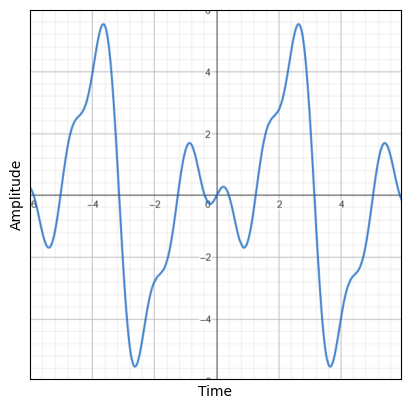

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.image as mpimg
img = mpimg.imread('./Photos/geo_function.png')
imgplot = plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.show()

Figure 1. The initial function with unknown formula structure

![Sinusoid_pi](Photos\sin_1_figure.png)

Figure 2. The sinusoid with a amplitude 2 projected on top of the function.

![Sinusoid_pi](Photos\sin_2_figure.png)

Figure 3. Addition of an additional sinusoid with an amplitude of 3 and period of $\pi$

![Sinusoid_pi](Photos\sin_3_figure.png)

Figure 4. Adding an additional sinusoid with period $\frac{2\pi}{3}$

![Sinusoid_pi](Photos\sin_4_figure.png)

Figure 5. Adding an additional sinusoid with an amplitude and a period of $\frac{\pi}{2}$

![Sinusoid_pi](Photos\sin_5_figure.png)

Figure 6: After the addition of another sinusoid with a period $\frac{2\pi}{5}$, the results is a almost identically close approximation to the original function.

In the below code we can better visualize, that the sum of all sinusoids is equal to the function we were approximation to.

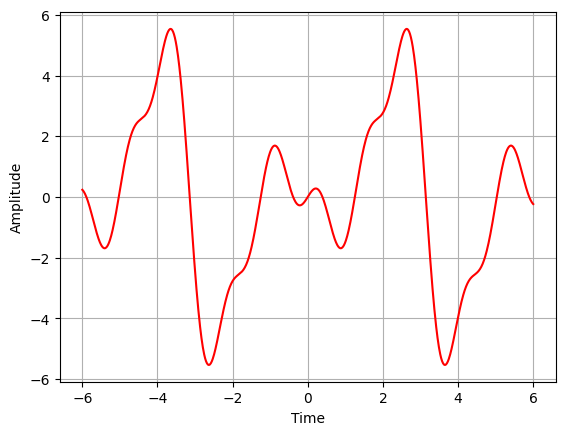

In [3]:
def sinosoid_sum(x):
    return 2*np.sin(x)-3*np.sin(2*x)+np.sin(3*x)-np.sin(4*x)/2+np.sin(5*x)

x = np.linspace(-6,6,1000)
y=sinosoid_sum(x)
plt.plot(x,y,c="r")
plt.grid(True,which="both")
plt.ylabel("Amplitude")
plt.xlabel("Time")
plt.show()

Figure 7: Approximated function with sum of sinusoids

<h1>Time domain vs frequency domain</h1>

In the above pictures, the signal has been represented in a <b>time domain</b>. This means the amplitudes of it can be observed how they change over time. This is useful as a visual understanding regarding how the signal wave looks and how often it repeats, however it is more difficult to understand which sinusoid frequencies it can be represented as.

This is where the <b>frequency domain</b> is very useful. It can display the power level of the signal in different frequency ranges. This means we can more easily visualize how big the amplittudes are at certain ranges of the signal.

If we take the above approximation of the sinoid sum used to approximate the initial function and apply the method known as fast Fourier transform, we can visualize in which frequencies for the sinusoids the function changes. The below graph is called a frequency domain graph, as well as spectrum plot.


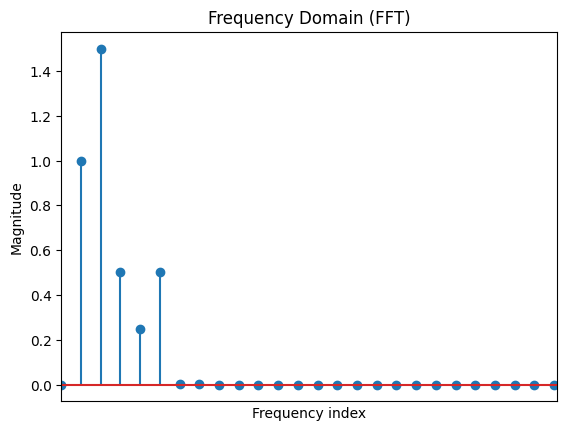

In [4]:
# Create x values
N = 1000
x = np.linspace(0, 2*np.pi, N)

# Sinusoid sum
signal = (2*np.sin(x)
          -3*np.sin(2*x)
          +np.sin(3*x)
          -0.5*np.sin(4*x)
          +np.sin(5*x))

# FFT
fft_vals = np.fft.fft(signal)
freq = np.fft.fftfreq(N, d=(x[1]-x[0]))

# Magnitude
magnitude = np.abs(fft_vals)/N

# ---- Frequency domain plot ----
plt.figure()
plt.stem(freq[:N//2], magnitude[:N//2])
plt.title("Frequency Domain (FFT)")
plt.xlabel("Frequency index")
plt.xticks([])
plt.xlim(0,4)
plt.ylabel("Magnitude")

plt.show()

Figure 8: Magnitude represents how strong a frequency component is. Only the positive value of each $\sin{x}$ function is diplayed. During the FFT decomposition of the signal, the sinusoid contains, both equal positive and negative frequencies, which means there is an equal negative magnitude, which needn't be displayed.

# Generating a Test Signal (Python Section)

Code cell:

Generate clean sine wave (music substitute)

Generate noise

Combine them

Plot:

Time domain signal

Frequency spectrum

Explain what is happeing.

After we have successfully displayed what time and frequency domain is regarding the sound wave, we can simulate real world situations by simulating a song and adding a noise, which could represent anything from rain, static or a random murmur. The song I have chosen "Piano Vintage Goat | Privcrypt" is a short piano sample loaded via tha Python library librosa. It creates a numpy.ndarray and each value represents the power or amplitude of the signal when measured, and we set how often we measure the signal by setting the sample rate. I have chosen the sample rate of 44100Hz, because it is commonly used standard for high-fidelity audio format for music, originally chosen for CDs.

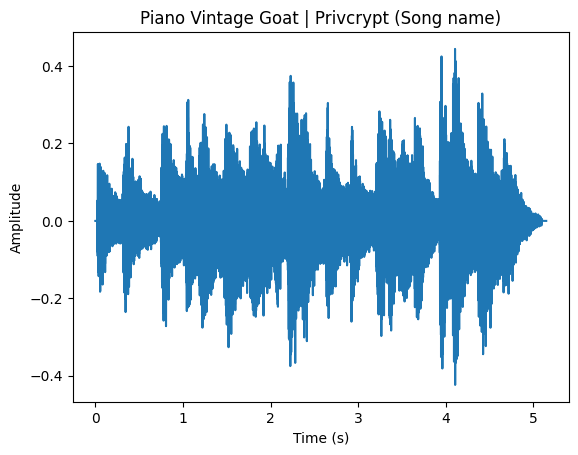

In [8]:
def generate_song_value_vector(song_title="short_piano_sample.mp3",sr=44100):
    """
    audio: numpy.ndarray representing the bit depth (the amplitude of the sound at each point)
    sr(sample rate): How often we capture the sound (by default sr=22050)
    """
    audio, sr = librosa.load(song_title, sr=sr)
    #audio shape represent the number of samples
    time=np.linspace(0,len(audio)/sr,len(audio))
    plt.plot(time,audio)
    plt.title("Piano Vintage Goat | Privcrypt (Song name)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
    return audio,sr

song_audio,sr = generate_song_value_vector()

Figure 9: The plot reprsents the song signal in time domain

We can generate noise by using the normal distribution or also known as Gaussian distribution by simulating static. We can control how strong, we want it to be by adjusting the noise strength.

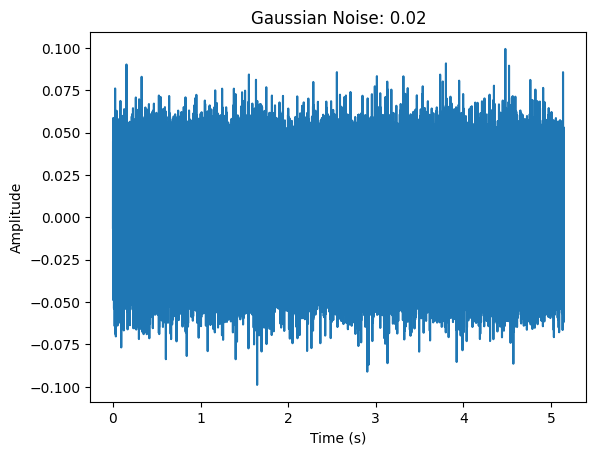

(array([-0.03374436,  0.02281117,  0.00149855, ..., -0.02613435,
        -0.01959919,  0.01722946], shape=(226944,)),
 0.02)

In [9]:
def generate_noise(audio,noise_strength=0.02):
    """
    Adding noise by applying the Gaussian distribution
    """
    noise = np.random.normal(0, noise_strength, audio.shape)
    return noise,noise_strength
    
noise,noise_strength = generate_noise(song_audio)
time = np.linspace(0,len(song_audio)/sr,len(song_audio))
plt.plot(time,noise)
plt.title(f"Gaussian Noise: {noise_strength}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

generate_noise(song_audio)

The noise is then added to the original song, and after we plot it we see that the original sound is slowly getting distorted. If we listen to the created audio of the noisy sounds, we can ascertain that the original sound is getting more and more difficult to hear. This can also be seen in the time domain of the sound with the added noise. Each value contains more power and the wave pattern is slowly disappering.

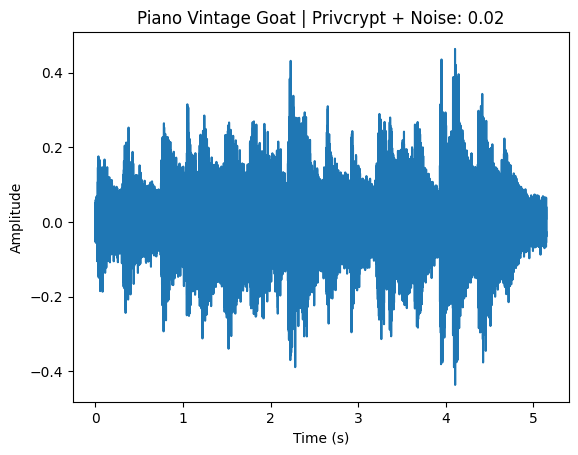

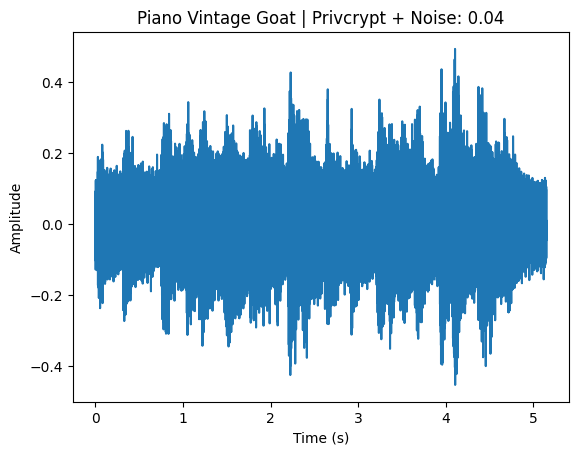

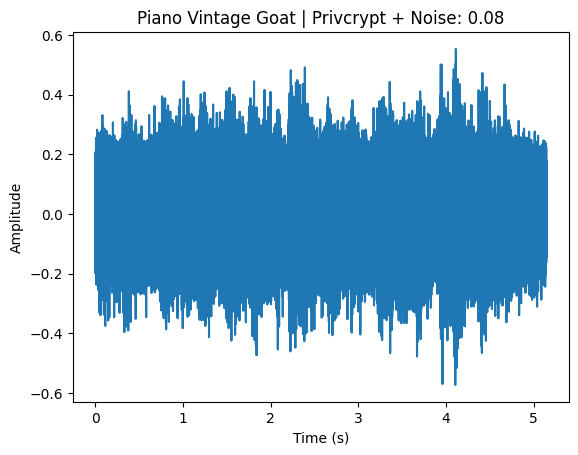

In [11]:
def add_noise_to_song(audio,noise_strength=0.02):
    """
    Adding noise by applying the Gaussian distribution
    """
    noise,noise_strength = generate_noise(audio,noise_strength)
    noisy_audio = audio + noise
    time=np.linspace(0,len(noisy_audio)/sr,len(noisy_audio))
    plt.plot(time,noisy_audio)
    plt.title(f"Piano Vintage Goat | Privcrypt + Noise: {noise_strength}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    return noisy_audio

noisy_audio = add_noise_to_song(song_audio)
sf.write("noisy_song.wav", noisy_audio, sr)

noise_strength_4 = 0.04
noisy_audio_4 = add_noise_to_song(song_audio,noise_strength_4)
sf.write("noisy_song_4.wav", noisy_audio_4, sr)
noise_strength_8 = 0.08
noisy_audio_8 = add_noise_to_song(song_audio,noise_strength_8)
sf.write("noisy_song_8.wav", noisy_audio_8, sr)

Figure 11: Noise increase effect on the song signal

If we plot the original sound on top of the noisy one we can observe how much the signal has been polluted. This can be seen in the below graphics.

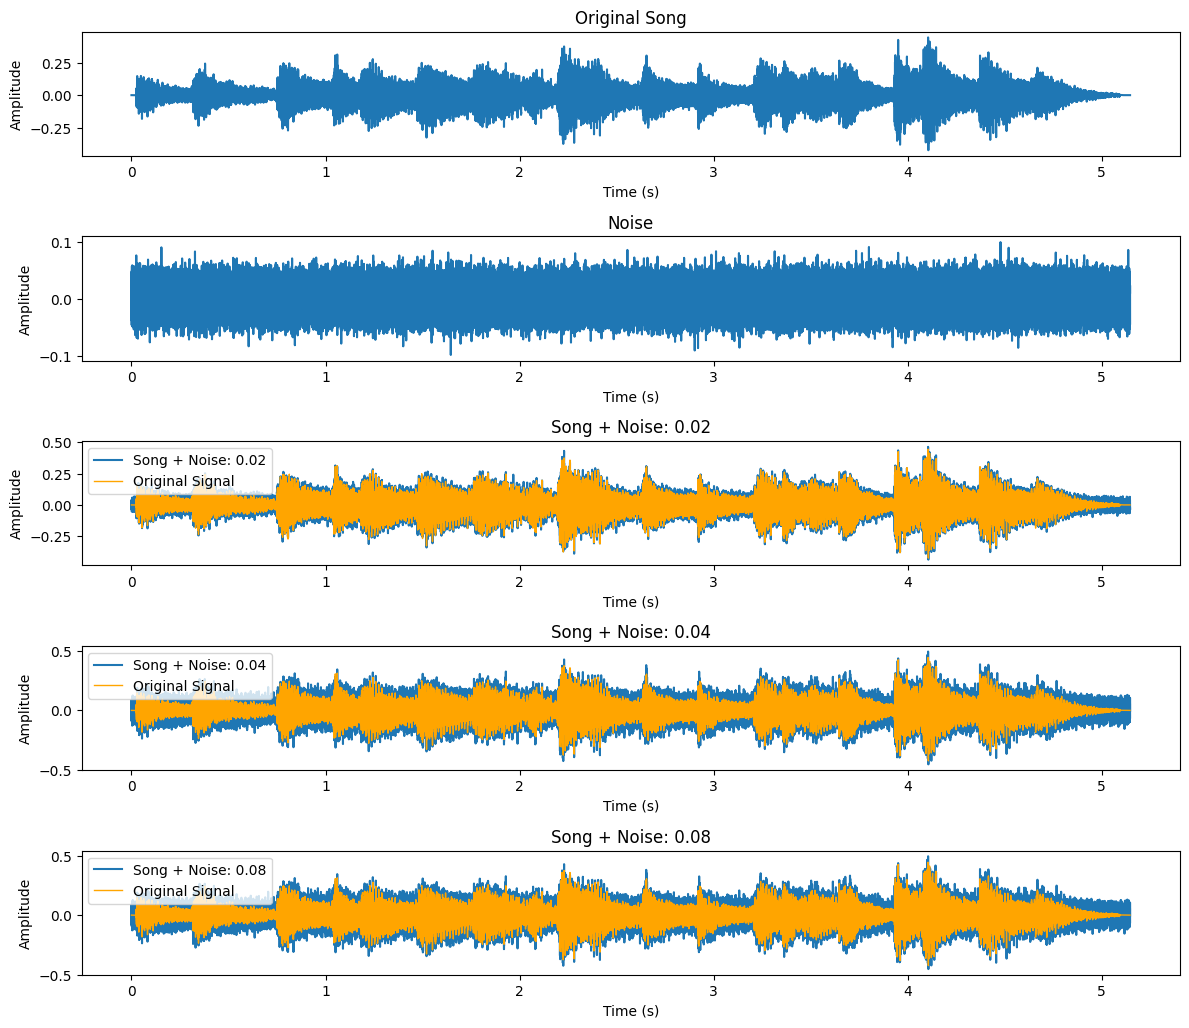

In [14]:
plt.figure(figsize=(12,12))

original_audio_plot = plt.subplot(6,1,1)
plt.plot(time, song_audio)
plt.title("Original Song")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(6,1,2)
plt.plot(time, noise)
plt.title("Noise")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

# Noisy + Overlay Original
ax = plt.subplot(6,1,3)
ax.plot(time, noisy_audio, label="Song + Noise: 0.02")
ax.plot(time, song_audio, color="orange", linewidth=1, label="Original Signal")
plt.legend()
plt.title("Song + Noise: 0.02")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

ax = plt.subplot(6,1,4)
ax.plot(time, noisy_audio_4, label="Song + Noise: 0.04")
ax.plot(time, song_audio, color="orange", linewidth=1, label="Original Signal")
plt.legend()
plt.title(f"Song + Noise: {noise_strength_4}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

ax = plt.subplot(6,1,5)
ax.plot(time, noisy_audio_4, label="Song + Noise: 0.08")
ax.plot(time, song_audio, color="orange", linewidth=1, label="Original Signal")
plt.legend()
plt.title(f"Song + Noise: {noise_strength_8}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

The above presentation is very useful to understand how the signal strength changes over time. However, in the below presentation we can see that the original song consists of frequencies in a range from 0Hz up until and around 5000Hz. The song I have used as an example consists mainly of piano notes, which are normally in the range between 27.5Hz, which is the note A0 and between 4186Hz, which is the note C8. This can be observed in our frequency domain graph, however the original audio could have contained noise, or the notes themselves could have been pitch shifted.

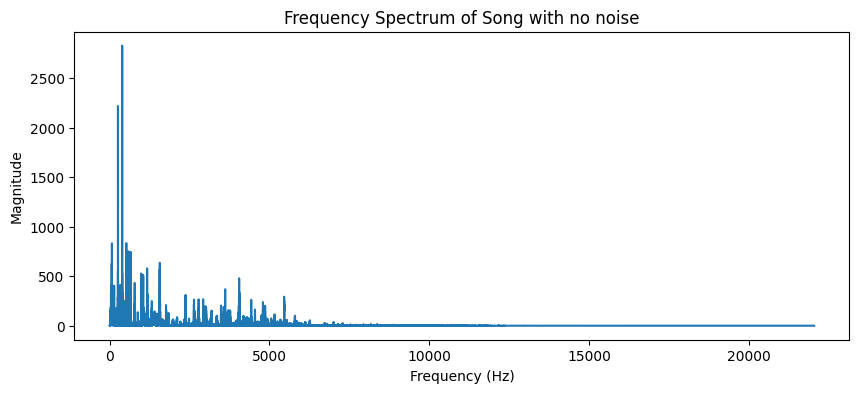

In [15]:
def generate_frequency_domain(song_audio):
    fft_values = np.fft.fft(song_audio)
    freqs = np.fft.fftfreq(len(song_audio), 1/sr)
    return fft_values,freqs

fft_values,freqs = generate_frequency_domain(song_audio)

magnitude = np.abs(fft_values)

plt.figure(figsize=(10,4))

plt.plot(freqs[:len(freqs)//2], magnitude[:len(magnitude)//2])

plt.title("Frequency Spectrum of Song with no noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

If we displayed the frequencies of the original audio on top of the spectrum plot of the signals containing noise, it can be observed that there are frequencies present all over the place. The additional frequencies is the noise representation, which are not that strong, however as it can be observed with the noise of 0.08, still relevant and it can not be ignored.

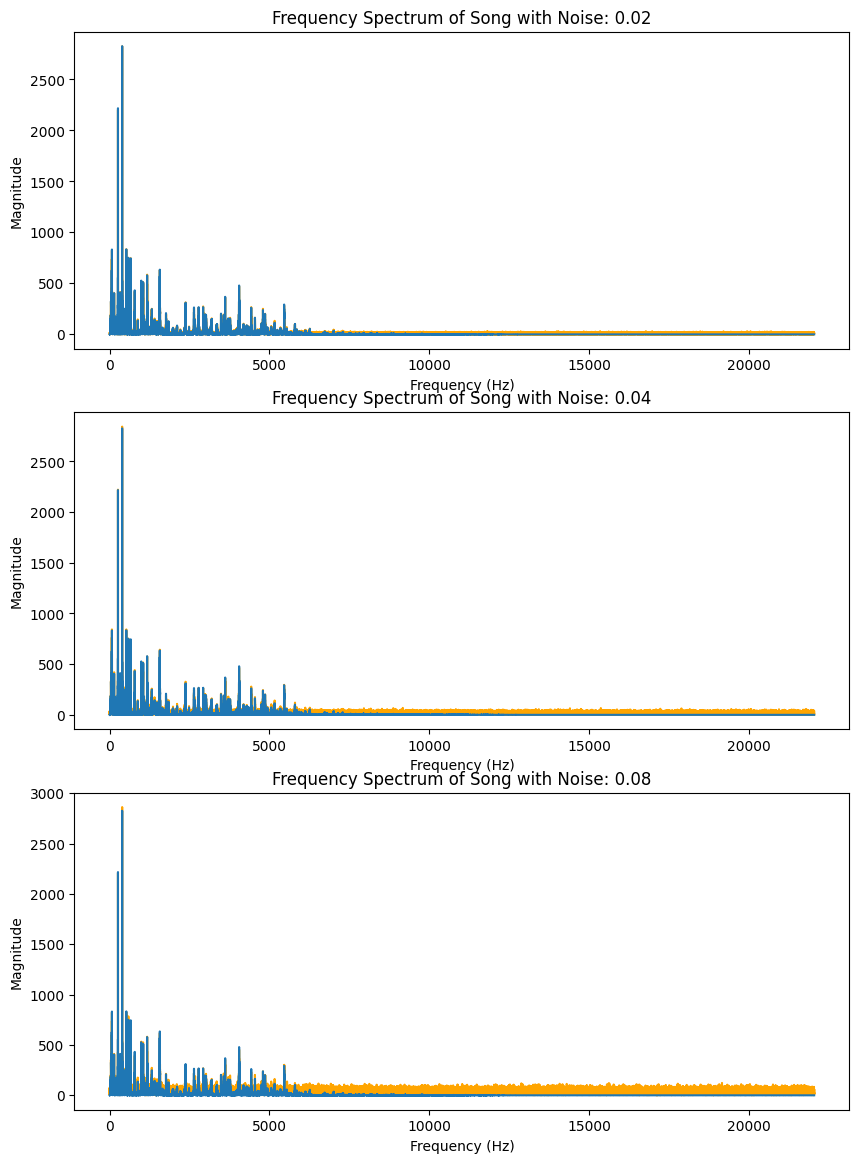

In [17]:
fft_values_2,freqs = generate_frequency_domain(noisy_audio)
fft_values_4,freqs = generate_frequency_domain(noisy_audio_4)
fft_values_8,freqs = generate_frequency_domain(noisy_audio_8)
magnitude_2 = np.abs(fft_values_2)
magnitude_4 = np.abs(fft_values_4)
magnitude_8 = np.abs(fft_values_8)
plt.figure(figsize=(10,14))

ax=plt.subplot(3,1,1)
ax.plot(freqs[:len(freqs)//2], magnitude_2[:len(magnitude_2)//2],color="orange")
ax.plot(freqs[:len(freqs)//2], magnitude[:len(magnitude)//2])
plt.title("Frequency Spectrum of Song with Noise: 0.02")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

ax=plt.subplot(3,1,2)
ax.plot(freqs[:len(freqs)//2], magnitude_4[:len(magnitude_4)//2],color="orange")
ax.plot(freqs[:len(freqs)//2], magnitude[:len(magnitude)//2])
plt.title("Frequency Spectrum of Song with Noise: 0.04")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

ax=plt.subplot(3,1,3)
ax.plot(freqs[:len(freqs)//2], magnitude_8[:len(magnitude_8)//2],color="orange")
ax.plot(freqs[:len(freqs)//2], magnitude[:len(magnitude)//2])
plt.title("Frequency Spectrum of Song with Noise: 0.08")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.show()

# Filtering in Frequency Domain

Compute FFT

Zero out noise frequencies

Apply inverse FFT

Explain:

What a low-pass filter does

What a notch filter does

Why filtering can distort signals


# Simulating Active Noise Cancellation

Now make it exciting:

Define noise signal 
𝑁(𝑡)

Create anti-noise 
−𝑁(𝑡)

Add them together

Show:

Before cancellation

After cancellation

Spectral comparison

Explain why phase alignment matters.